In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [7]:
df.shape

(30, 3)

In [9]:
df.isna().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [12]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
dtype: bool

In [13]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [16]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


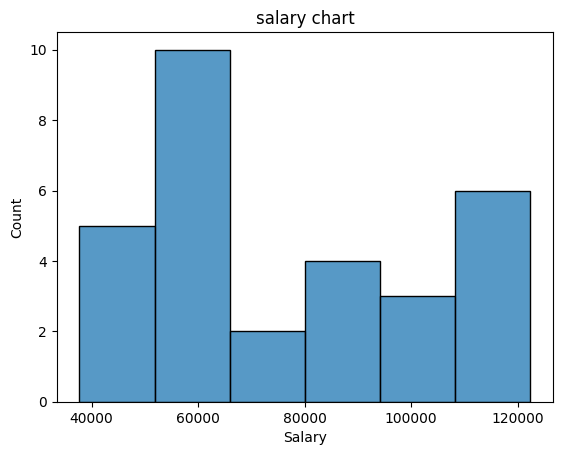

<Figure size 640x480 with 0 Axes>

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Salary'])
plt.title('salary chart')
plt.show()
plt.savefig("../images/salarychart.png")

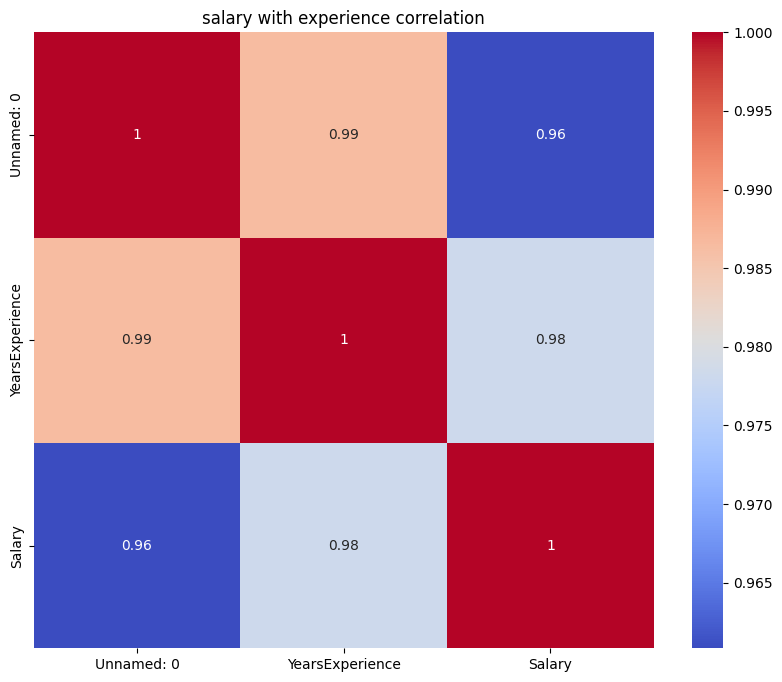

<Figure size 640x480 with 0 Axes>

In [64]:
df_corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(df_corr , annot = True , cmap = 'coolwarm')
plt.title('salary with experience correlation')
plt.show()
plt.savefig("../images/experiencecorrelation.png")

In [60]:
df_corr

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('Salary' , axis = 1)
y = df['Salary']
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)


In [33]:
print(f"size of train data {X_train.shape}")
print(f"size of test data {X_test.shape}")

size of train data (22, 2)
size of test data (8, 2)


In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)
prediction = model.predict(X_test)
prediction

array([116390.84646001,  69833.91426648, 102900.55544831,  72927.42427729,
        55354.9937336 ,  60553.38423405, 124023.66062383, 108098.94594876])

In [43]:
df.loc[23]

Unnamed: 0             23.0
YearsExperience         8.3
Salary             113813.0
Name: 23, dtype: float64

In [55]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

print(r2_score(y_test , prediction))
print(mean_absolute_error(y_test , prediction))
print(mean_squared_error(y_test , prediction))


0.9288315574563337
5267.860772052848
42303342.1517816


In [57]:
import pickle

pickle.dump(
    model,
    open("../model.pkl", "wb")
)